## 1. The Representation Problem

Before we can apply **ANY** machine learning algorithm to text, we face one non-negotiable requirement:
> Machine learning algorithms only understand numbers. <br>

A sentence like `"The cat sat on the mat"` means nothing to a model.
So the first question in NLP is not **"how do I train a model?"** — it is:<br>

<span style="color: rgba(42, 123, 155, 1)">
"How do I turn language into a format that math can operate on?"
</span>

## 2. Feature Vectors

A **feature vector** is a list of numbers that represents an object (in our case, a word or a document).
Think of it like a row in a spreadsheet — each column is a feature, each value is a number.

**Example — representing a house for price prediction:**

```markdown
[bedrooms=3, bathrooms=2, area_sqft=1500, age_years=10, has_pool=0]
```

That 5-number list is the feature vector of the house. For text, we need to do the same thing — turn words and documents into a fixed-length list of numbers.

## 3. The Obvious Idea: One-Hot Encoding

The simplest approach: build a vocabulary of all unique words. For each word, create a vector the length of the vocabulary. Put a `1` in the position of that word, `0` everywhere else.

**Example:**

Vocabulary: `[cat, dog, sat, mat, love]`   → size = `5`

cat  = `[1, 0, 0, 0, 0]`
dog  = `[0, 1, 0, 0, 0]`
sat  = `[0, 0, 1, 0, 0]`
love = `[0, 0, 0, 0, 1]`

In [5]:
vocabulary = ['cat', 'dog', 'sat', 'mat', 'love']

def one_hot(word, vocab):
    vector = [0] * len(vocab)
    if word in vocab:
        vector[vocab.index(word)] = 1
    return vector

print('cat  ->', one_hot('cat',  vocabulary))
print('dog  ->', one_hot('dog',  vocabulary))
print('love ->', one_hot('love', vocabulary)) 

cat  -> [1, 0, 0, 0, 0]
dog  -> [0, 1, 0, 0, 0]
love -> [0, 0, 0, 0, 1]


### 3.1 Why it fails
One-hot looks clean. But it breaks in three fundamental ways:

#### Problem 1 — Massive Dimensionality (Sparse Vectors)
English vocabulary ≈ 170,000 words. Every word becomes a **170,000-dimensional vector** with exactly one `1` and 169,999 zeros.

```raw
Vocabulary size:          50,000 words
Each word vector:         50,000 numbers
200-word document:        200 × 50,000 = 10,000,000 numbers
1 million documents:      10,000,000,000,000 numbers
```
Almost all of these are zero. Zero information, massive cost.<br>
These are called **sparse vectors** — computationally expensive and informationally empty.


#### Problem 2 — No Semantic Meaning

In one-hot space, **every word is equally distant from every other word.**

In [7]:
import numpy as np

king  = np.array([1, 0, 0, 0, 0])
queen = np.array([0, 1, 0, 0, 0])
table = np.array([0, 0, 1, 0, 0])

dist_king_queen = np.linalg.norm(king - queen) 
dist_king_table = np.linalg.norm(king - table)  

print('Distance between "king" and "queen":', dist_king_queen)
print('Distance between "king" and "table":', dist_king_table)


Distance between "king" and "queen": 1.4142135623730951
Distance between "king" and "table": 1.4142135623730951


- `distance('king', 'queen')` = same as `distance('king', 'table')`.
- A model trained on `'happy'` cannot generalize to `'joyful'`.
- Synonyms and related words share zero signal.

#### Problem 3 — No Document Representation

One-hot gives a vector *per word*. But how do we represent a whole sentence or document?

Adding one-hot vectors loses all structure. There is no principled way to go from word vectors to a document vector using one-hot encoding.

**Because one-hot encoding fails, we need smarter representations.**

*Each technique in this unit solves one or more of these three problems.*

| Technique | Problem It Solves |
|:--|:---|
| Bag of Words | Document representation from word counts |
| N-grams | Adds local sequential context |
| TF-IDF | Makes discriminative words more important |
| Cosine Similarity | Measures semantic distance between document vectors |
| Naive Bayes | First full text classifier on top of these representations |

## 4. Bag of Words (BoW)

### 4.1 The Problem BoW Solves

One-hot encodes individual words. We need to represent **entire documents** as a single vector.

> **The BoW idea:** Represent a document by counting how many times each vocabulary word appears. Ignore word order. Just count.

### 4.2 How It Works — Step by Step

1. Collect all documents → **build vocabulary** (all unique words)
2. **Count Word Occurrences** – Count how many times each word appears in each document.
3. For each document, create a vector of size `|vocabulary|`
4. Fill each position with the count of how many times that word appears

**Manual example:**

```raw
D1: "the cat sat on the mat"
D2: "the dog sat on the log"
D3: "the cat and the dog played"

Vocabulary: [the, cat, sat, on, mat, dog, log, and, played]

D1 vector: [2, 1, 1, 1, 1, 0, 0, 0, 0]   ('the' appears twice, 'cat' once...)
D2 vector: [2, 0, 1, 1, 0, 1, 1, 0, 0]
D3 vector: [2, 1, 0, 0, 0, 1, 0, 1, 1]
```

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
docs = [
    'the cat sat on the mat',
    'the dog sat on the log',
    'the cat and the dog played'
]
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(docs)
df = pd.DataFrame(X.toarray(),
                  columns=vectorizer.get_feature_names_out(),
                  index=['D1', 'D2', 'D3'])
display(df)

,and,cat,dog,log,mat,on,played,sat,the
D1,0,1,0,0,1,1,0,1,2
D2,0,0,1,1,0,1,0,1,2
D3,1,1,1,0,0,0,1,0,2


### 4.3 Real-World Application: Spam Filter

In [21]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

emails = [
    'win free money now click here',
    'free prize claim wer reward',
    'meeting at 3pm tomorrow agenda',
    'please review the attached report',
    'congratulations we won a prize',
    'project update call scheduled'
]
labels = ['spam', 'spam', 'ham', 'ham', 'spam', 'ham']

model = Pipeline([('bow', CountVectorizer()), ('clf', MultinomialNB())])
model.fit(emails, labels)

test_emails = [
    'free money reward click',
    'team meeting next week'
]
df = pd.DataFrame({'email': test_emails, 'predicted_label': model.predict(test_emails)}, index=['D1', 'D2'])
display(df)

,email,predicted_label
D1,free money reward click,spam
D2,team meeting next week,ham


| ✅ Captures | ❌ Misses |
|---|---|
| Which words are present | Word order / sequence |
| Word frequency in the document | Grammar and syntax |
| Document-level statistics | Semantic similarity between words |
| Relative word importance (raw) | Context — `'not good'` = same tokens as `'good'` |

⚠️ **The Order Problem:** `"The cat bit the dog"` and `"The dog bit the cat"` have **identical** BoW vectors. This is the motivation for N-grams.

## 5. N-grams: From Text to Numbers

A N-gram is a **contiguous sequence of N words** from a text.

| N | Name | Example from `"the food was not good"` |
|---|---|---|
| 1 | Unigram | `the`, `food`, `was`, `not`, `good` |
| 2 | Bigram | `(the food)`, `(food was)`, `(was not)`, `(not good)` |
| 3 | Trigram | `(the food was)`, `(food was not)`, `(was not good)` |
| 4 | 4-gram | `(the food was not)`, `(food was not good)` |

### 5.1 How N-grams are transformed into numbers

 N-grams themselves are just strings. To feed them to a model, they go through the **same BoW pipeline** — but with N-gram tokens instead of single-word tokens.

**Step-by-step:**

```markdown
Input sentence: "the cat sat on mat"

**Step 1 — Tokenize into N-grams:
  Unigrams:  ['the', 'cat', 'sat', 'on', 'mat']
  Bigrams:   ['the cat', 'cat sat', 'sat on', 'on mat']
  Trigrams:  ['the cat sat', 'cat sat on', 'sat on mat']

**Step 2 — Build vocabulary from all N-grams in the corpus:
  Bigram vocab: ['the cat', 'cat sat', 'sat on', 'on mat', 'the dog', ...]

**Step 3 — Count occurrences per document (same as BoW):
  D1 bigram vector: [1, 1, 1, 1, 0, 0, ...]
                     ↑              ↑
                 'the cat'=1     'the dog'=0
```                
**The output is the same type of count vector as BoW — just with N-gram features instead of word features.**

> The following plots show exactly how text breaks into N-grams and how each generates a count matrix.

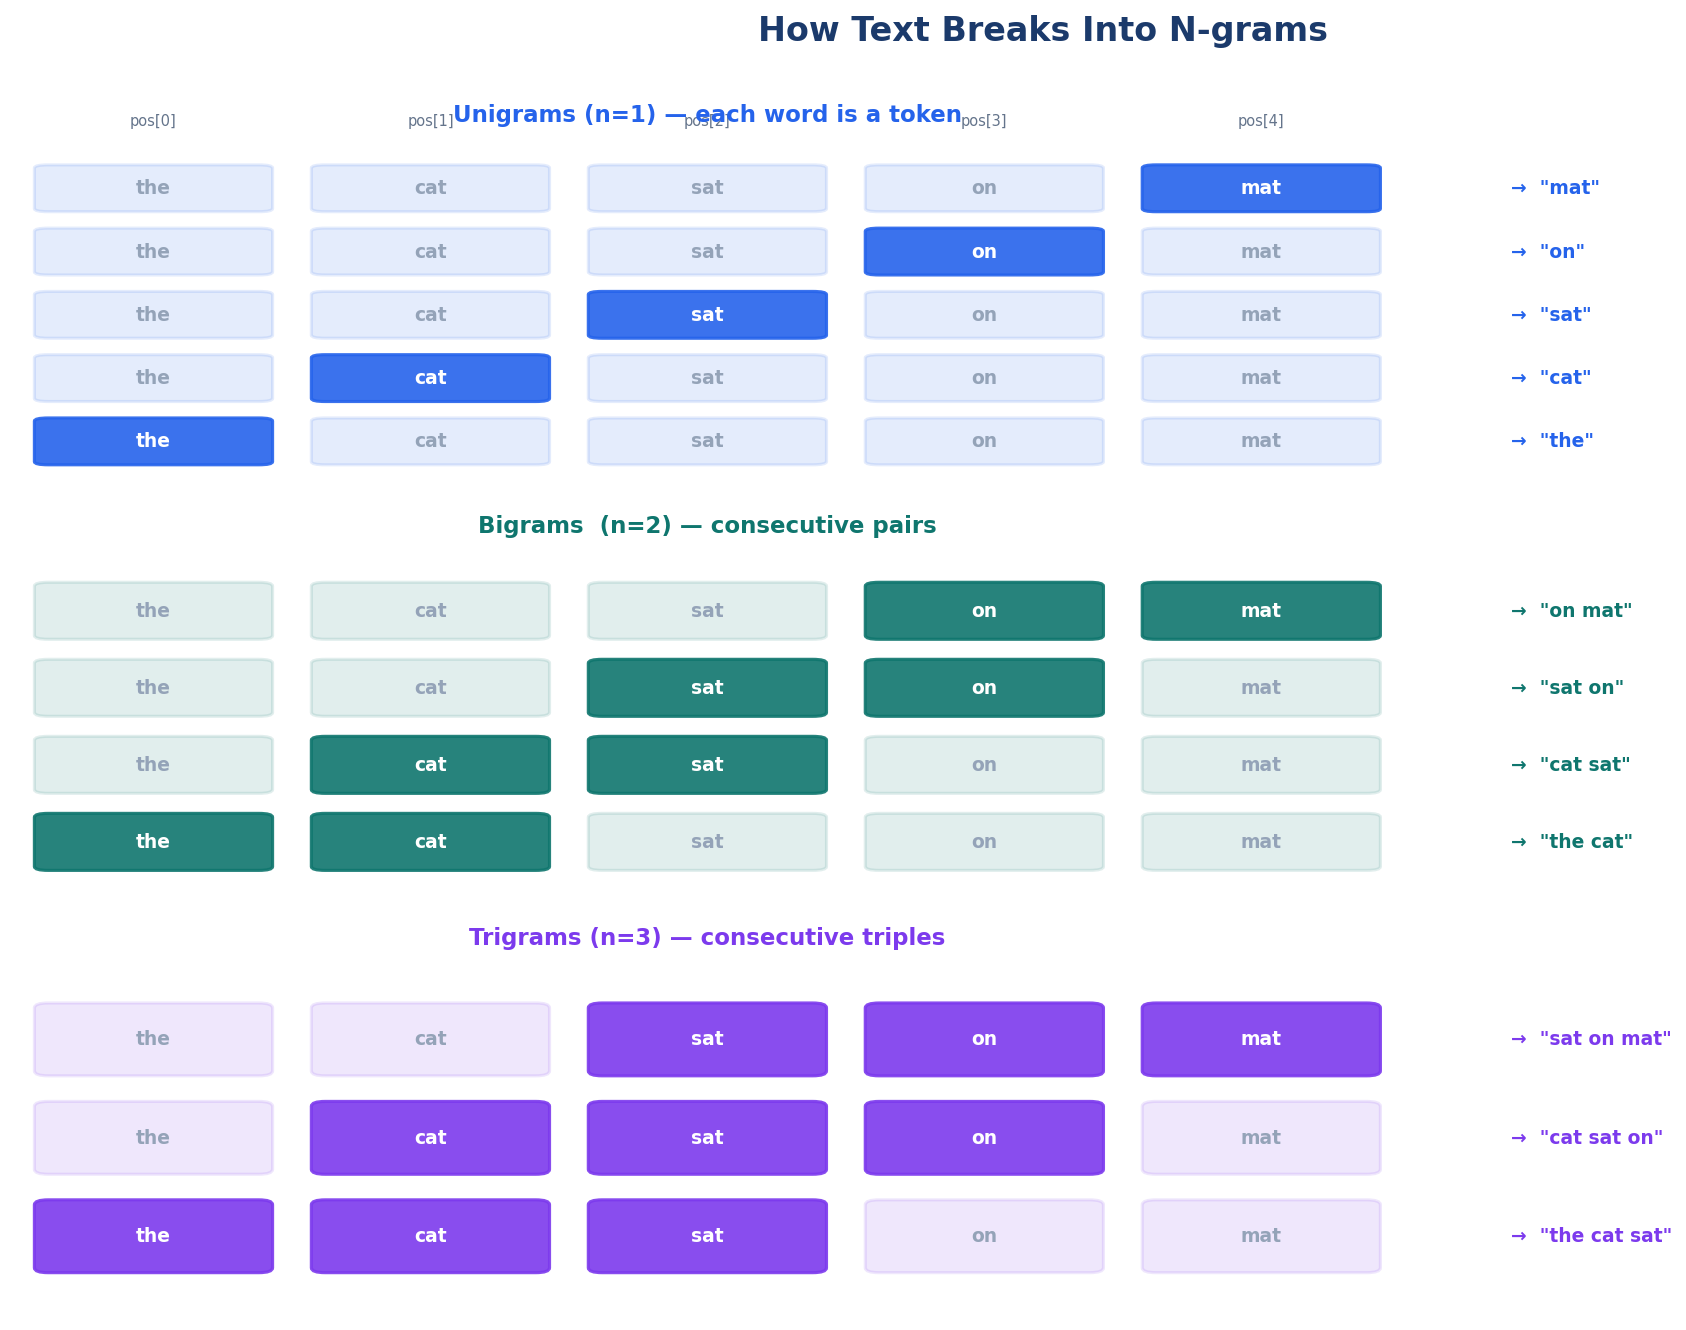

In [26]:
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
    "This is NLP",
    "This is deep learning"
    ]
vectorizer = CountVectorizer(ngram_range=(1, 3))
X = vectorizer.fit_transform(corpus)
print("N-grams: ", vectorizer.get_feature_names_out())
print("vocabulary count: ", len(vectorizer.get_feature_names_out()))
print("Count Matrix:\n", X.toarray())
df = pd.DataFrame(X.toarray(),columns=vectorizer.get_feature_names_out(),index=['D1','D2'])
display(df)

N-grams:  ['deep' 'deep learning' 'is' 'is deep' 'is deep learning' 'is nlp'
 'learning' 'nlp' 'this' 'this is' 'this is deep' 'this is nlp']
vocabulary count:  12
Count Matrix:
 [[0 0 1 0 0 1 0 1 1 1 0 1]
 [1 1 1 1 1 0 1 0 1 1 1 0]]


,deep,deep learning,is,is deep,is deep learning,is nlp,learning,nlp,this,this is,this is deep,this is nlp
D1,0,0,1,0,0,1,0,1,1,1,0,1
D2,1,1,1,1,1,0,1,0,1,1,1,0


### 5.2 unigrams

A unigram model in NLP is the simplest N-gram language model that treats each word in a text sequence independently, ignoring context and word order.

In [30]:
corpus = [
    "This movie is very good",
    "This movie is not good"
]

# Create a unigram vectorizer
vectorizer = CountVectorizer(ngram_range=(1, 1))    ## combination of (1,1) and (2,2) and (3,3)
X = vectorizer.fit_transform(corpus)

# Get feature names
print("Unigrams:", vectorizer.get_feature_names_out())
print("Vocabulary count: ", vectorizer.vocabulary_)
# Convert to array
print("Frequency Matrix:\n", X.toarray())
df = pd.DataFrame(X.toarray(),columns=vectorizer.get_feature_names_out(),index=['D1','D2'])
display(df)

Unigrams: ['good' 'is' 'movie' 'not' 'this' 'very']
Vocabulary count:  {'this': 4, 'movie': 2, 'is': 1, 'very': 5, 'good': 0, 'not': 3}
Frequency Matrix:
 [[1 1 1 0 1 1]
 [1 1 1 1 1 0]]


,good,is,movie,not,this,very
D1,1,1,1,0,1,1
D2,1,1,1,1,1,0


in these unigrams:
- Vectors are quite similar.
- Only difference: very in sentence 1 vs not in sentence 2.
- This means cosine distance or Euclidean distance between them is small.

### 5.3 bigrams

- A bigram in NLP is a contiguous sequence of two consecutive words or characters, used as a fundamental, simple language model to predict the probability of a word based on the one immediately preceding it.
- It operates on the Markov assumption, capturing short-range context for tasks like autocomplete, spell-checking, and speech recognition.

In [29]:
vectorizer = CountVectorizer(ngram_range=(2, 2))    ## combination of (1,1) and (2,2) and (3,3)
X = vectorizer.fit_transform(corpus)

# Get feature names
print("Bigrams:", vectorizer.get_feature_names_out())
print("Vocabulary count: ", vectorizer.vocabulary_)
# Convert to array
print("Frequency Matrix:\n", X.toarray())
df = pd.DataFrame(X.toarray(),columns=vectorizer.get_feature_names_out(),index=['D1','D2'])
display(df)

Bigrams: ['is not' 'is very' 'movie is' 'not good' 'this movie' 'very good']
Vocabulary count:  {'this movie': 4, 'movie is': 2, 'is very': 1, 'very good': 5, 'is not': 0, 'not good': 3}
Frequency Matrix:
 [[0 1 1 0 1 1]
 [1 0 1 1 1 0]]


,is not,is very,movie is,not good,this movie,very good
D1,0,1,1,0,1,1
D2,1,0,1,1,1,0


Using Bigram,
- Now the vectors differ more significantly.
- Bigram is very and very good only exist in sentence 1.
- Bigram is not and not good only exist in sentence 2.
- Higher discriminative power than unigrams.

### 5.3 trigrams
- A trigram in Natural Language Processing (NLP) is a contiguous sequence of three adjacent items—typically words, letters, or syllables—from a given sample of text. 
- Trigrams are a specific type of n-gram ($n=3$) used to capture local context for language modeling, text prediction, speech recognition, and spell-checking. 

In [32]:
vectorizer = CountVectorizer(ngram_range=(3, 3))
X = vectorizer.fit_transform(corpus)

# Get feature names
print("Trigrams:", vectorizer.get_feature_names_out())
print("Vocabulary count: ", vectorizer.vocabulary_)
# Convert to array
print("Frequency Matrix:\n", X.toarray())
df = pd.DataFrame(X.toarray(),columns=vectorizer.get_feature_names_out(),index=['D1','D2'])
display(df)

Trigrams: ['is not good' 'is very good' 'movie is not' 'movie is very'
 'this movie is']
Vocabulary count:  {'this movie is': 4, 'movie is very': 3, 'is very good': 1, 'movie is not': 2, 'is not good': 0}
Frequency Matrix:
 [[0 1 0 1 1]
 [1 0 1 0 1]]


,is not good,is very good,movie is not,movie is very,this movie is
D1,0,1,0,1,1
D2,1,0,1,0,1


Using Trigrams,
- Even sharper contrast than bigrams.
- No shared trigrams between the two sentences.
- The vectors are now much farther apart.

### 5.4 Combined N-grams(1,2,3)

In [33]:
vectorizer = CountVectorizer(ngram_range=(1, 3))
X = vectorizer.fit_transform(corpus)

# Get feature names
print("ngrams:", vectorizer.get_feature_names_out())
print("Vocabulary count: ", vectorizer.vocabulary_)
# Convert to array
print("Frequency Matrix:\n", X.toarray())
df = pd.DataFrame(X.toarray(),columns=vectorizer.get_feature_names_out(),index=['D1','D2'])
display(df)

ngrams: ['good' 'is' 'is not' 'is not good' 'is very' 'is very good' 'movie'
 'movie is' 'movie is not' 'movie is very' 'not' 'not good' 'this'
 'this movie' 'this movie is' 'very' 'very good']
Vocabulary count:  {'this': 12, 'movie': 6, 'is': 1, 'very': 15, 'good': 0, 'this movie': 13, 'movie is': 7, 'is very': 4, 'very good': 16, 'this movie is': 14, 'movie is very': 9, 'is very good': 5, 'not': 10, 'is not': 2, 'not good': 11, 'movie is not': 8, 'is not good': 3}
Frequency Matrix:
 [[1 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 1]
 [1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 0 0]]


,good,is,is not,is not good,is very,is very good,movie,movie is,movie is not,movie is very,not,not good,this,this movie,this movie is,very,very good
D1,1,1,0,0,1,1,1,1,0,1,0,0,1,1,1,1,1
D2,1,1,1,1,0,0,1,1,1,0,1,1,1,1,1,0,0


This approach mixes all the advantages of different levels of granularity.

### 5.5 Bag of N-grams
**Bag of N-grams** is exactly what it sounds like: instead of (or in addition to) individual words, the "bag" contains N-gram tokens. It is the natural generalization of BoW.

1. Bag of Unigrams of D1 ("the cat sat on mat"):
```
  {'the': 1, 'cat': 1, 'sat': 1, 'on': 1, 'mat': 1}
```
2. Bag of Bigrams of D1:
```
  {'the cat': 1, 'cat sat': 1, 'sat on': 1, 'on mat': 1}
```
3. Bag of Trigrams of D1:
```
  {'the cat sat': 1, 'cat sat on': 1, 'sat on mat': 1}
```
4. Combined Bag of (1,2,3)-grams of D1:
```
  {'the':1, 'cat':1, 'sat':1, 'on':1, 'mat':1,
   'the cat':1, 'cat sat':1, 'sat on':1, 'on mat':1,
   'the cat sat':1, 'cat sat on':1, 'sat on mat':1}
```

In [71]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

corpus = [
    'the cat sat on the mat',
    'the dog sat on the log',
    'the cat and the dog played'
]

# Bag of N-grams: include unigrams, bigrams, and trigrams
vectorizer = CountVectorizer(ngram_range=(1, 3))
X = vectorizer.fit_transform(corpus)
print("Vocabulary: ", vectorizer.vocabulary_)
print(f'Vocabulary size: {len(vectorizer.vocabulary_)} features')


df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=['D1', 'D2', 'D3']
)
# Show a sample of columns
display(df.iloc[:, :10])

Vocabulary:  {'the': 22, 'cat': 3, 'sat': 19, 'on': 14, 'mat': 13, 'the cat': 23, 'cat sat': 6, 'sat on': 20, 'on the': 15, 'the mat': 30, 'the cat sat': 25, 'cat sat on': 7, 'sat on the': 21, 'on the mat': 17, 'dog': 8, 'log': 12, 'the dog': 26, 'dog sat': 10, 'the log': 29, 'the dog sat': 28, 'dog sat on': 11, 'on the log': 16, 'and': 0, 'played': 18, 'cat and': 4, 'and the': 1, 'dog played': 9, 'the cat and': 24, 'cat and the': 5, 'and the dog': 2, 'the dog played': 27}
Vocabulary size: 31 features


,and,and the,and the dog,cat,cat and,cat and the,cat sat,cat sat on,dog,dog played
D1,0,0,0,1,0,0,1,1,0,0
D2,0,0,0,0,0,0,0,0,1,0
D3,1,1,1,1,1,1,0,0,1,1


### 5.6 Visualizing N-grams

In [34]:
#| code-fold: true
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Function to process n-grams and visualize
def process_and_visualize(corpus, ngram_range, title):
    # Vectorization
    vectorizer = CountVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(corpus).toarray()

    # Cosine Similarity
    similarity = cosine_similarity(X)[0, 1]

    print(f"\n=== {title} ===")
    print("Feature Names:", vectorizer.get_feature_names_out())
    print("Vectors:\n", X)
    print(f"Cosine Similarity: {similarity:.4f}")

    # PCA for 2D projection
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Plot
    plt.figure()
    plt.title(f"{title} (Similarity: {similarity:.2f})")
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=['blue', 'red'])
    for i, txt in enumerate(corpus):
        plt.annotate(f"S{i+1}", (X_pca[i, 0], X_pca[i, 1]), fontsize=12)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()


=== Unigram Representation Corpus ===
Feature Names: ['good' 'is' 'movie' 'not' 'this' 'very']
Vectors:
 [[1 1 1 0 1 1]
 [1 1 1 1 1 0]]
Cosine Similarity: 0.8000


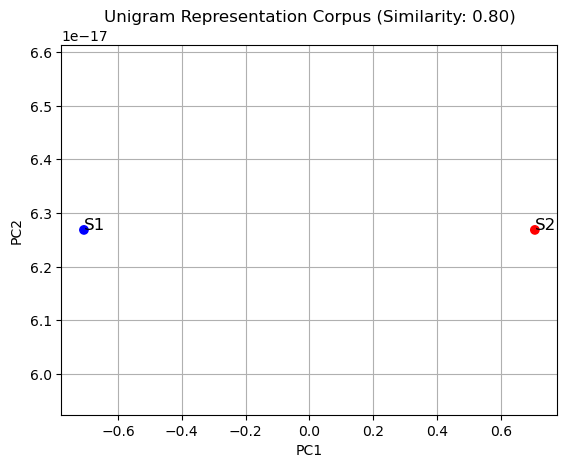


=== Bigram Representation Corpus ===
Feature Names: ['is not' 'is very' 'movie is' 'not good' 'this movie' 'very good']
Vectors:
 [[0 1 1 0 1 1]
 [1 0 1 1 1 0]]
Cosine Similarity: 0.5000


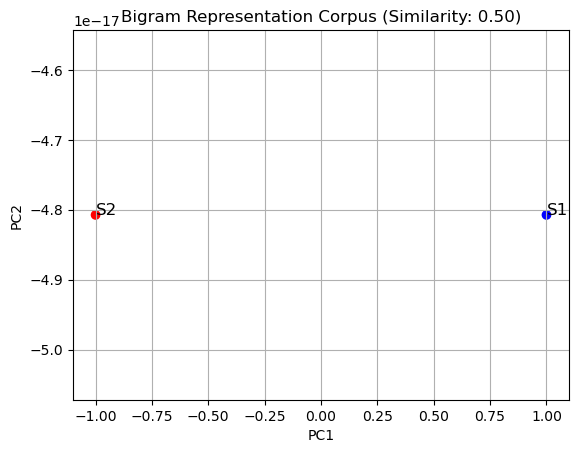


=== Trigram Representation Corpus ===
Feature Names: ['is not good' 'is very good' 'movie is not' 'movie is very'
 'this movie is']
Vectors:
 [[0 1 0 1 1]
 [1 0 1 0 1]]
Cosine Similarity: 0.3333


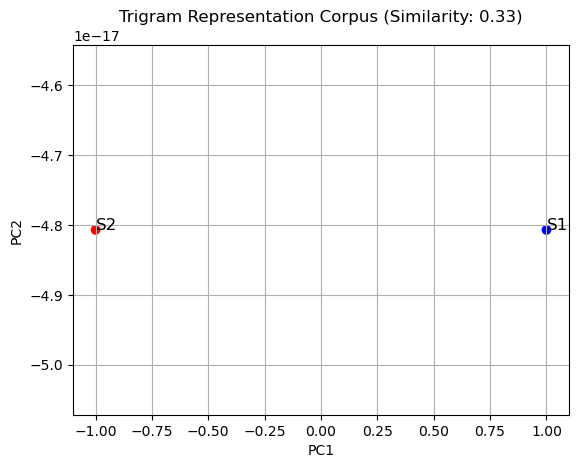


=== Ngram Representation Corpus ===
Feature Names: ['good' 'is' 'is not' 'is not good' 'is very' 'is very good' 'movie'
 'movie is' 'movie is not' 'movie is very' 'not' 'not good' 'this'
 'this movie' 'this movie is' 'very' 'very good']
Vectors:
 [[1 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 1]
 [1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 0 0]]
Cosine Similarity: 0.5833


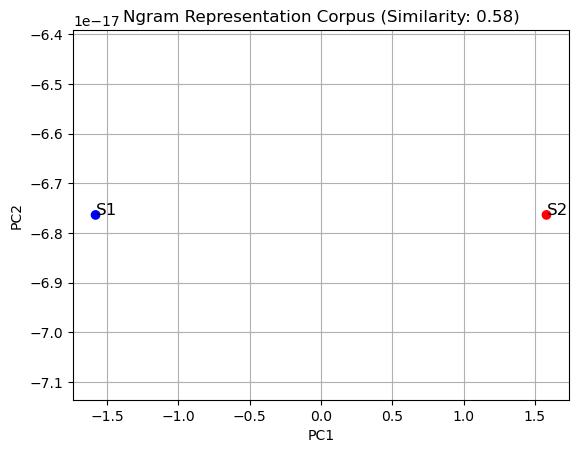

In [52]:
corpus1 = [
    "This movie is very good",
    "This movie is not good",
]

process_and_visualize(corpus1, (1,1), "Unigram Representation Corpus")
process_and_visualize(corpus1, (2,2), "Bigram Representation Corpus")
process_and_visualize(corpus1, (3,3), "Trigram Representation Corpus")
process_and_visualize(corpus1, (1,3), "Ngram Representation Corpus")



=== Unigram Representation Corpus ===
Feature Names: ['amazing' 'good' 'is' 'movie' 'this' 'very']
Vectors:
 [[0 1 1 1 1 1]
 [1 0 0 1 0 0]]
Cosine Similarity: 0.3162


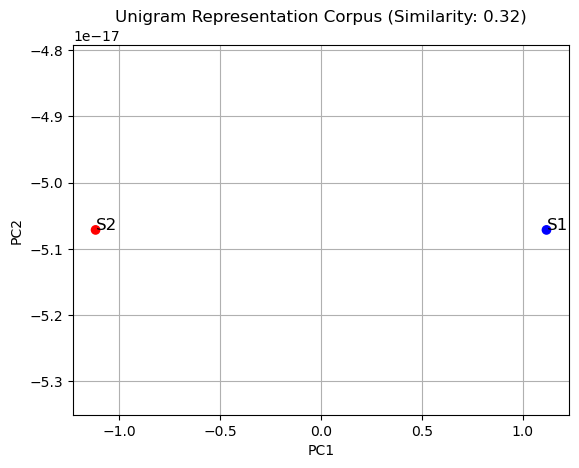


=== Bigram Representation Corpus ===
Feature Names: ['amazing movie' 'is very' 'movie is' 'this movie' 'very good']
Vectors:
 [[0 1 1 1 1]
 [1 0 0 0 0]]
Cosine Similarity: 0.0000


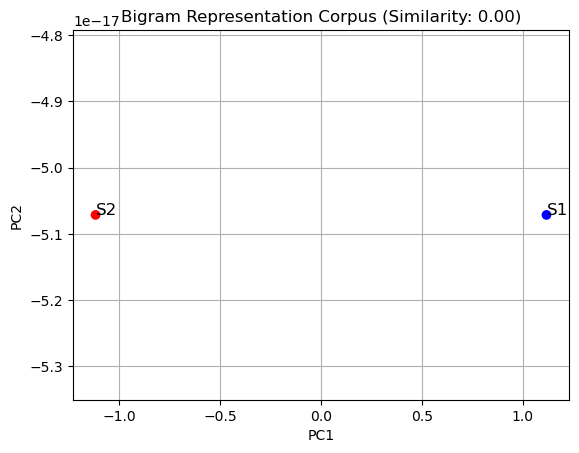


=== Trigram Representation Corpus ===
Feature Names: ['is very good' 'movie is very' 'this movie is']
Vectors:
 [[1 1 1]
 [0 0 0]]
Cosine Similarity: 0.0000


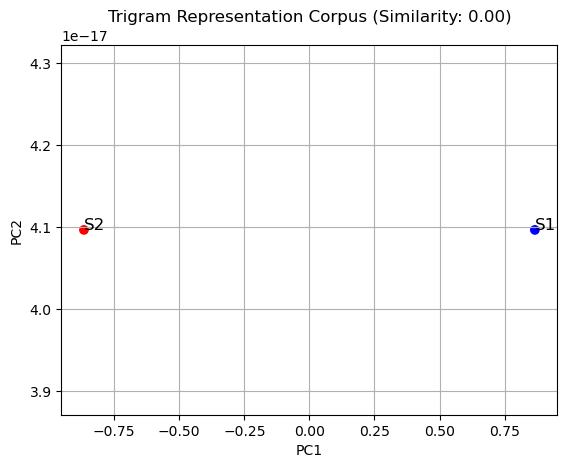


=== Ngram Representation Corpus ===
Feature Names: ['amazing' 'amazing movie' 'good' 'is' 'is very' 'is very good' 'movie'
 'movie is' 'movie is very' 'this' 'this movie' 'this movie is' 'very'
 'very good']
Vectors:
 [[0 0 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 0 0 0 0 1 0 0 0 0 0 0 0]]
Cosine Similarity: 0.1667


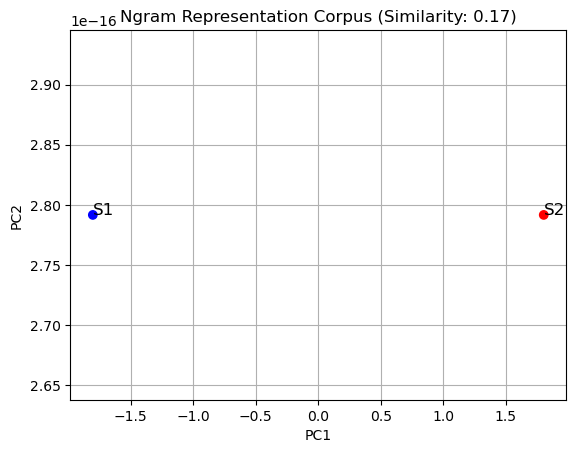

In [54]:
corpus1 = [
    "This movie is very good",
    "Amazing movie",
]

process_and_visualize(corpus1, (1,1), "Unigram Representation Corpus")
process_and_visualize(corpus1, (2,2), "Bigram Representation Corpus")
process_and_visualize(corpus1, (3,3), "Trigram Representation Corpus")
process_and_visualize(corpus1, (1,3), "Ngram Representation Corpus")

#### Why combining unigrams and bigrams?

Combine unigrams + bigrams (`ngram_range=(1, 2)`) for a good balance between context and sparsity.

In [134]:
# only unigrams

corpus = ['dog bites man', 'man bites dog']
vectorizer = CountVectorizer(ngram_range=(1,1))
X = vectorizer.fit_transform(corpus)

print("All unigrams:", vectorizer.get_feature_names_out())
print("Frequency Matrix:\n", X.toarray())
print("Cosine similarity: ", cosine_similarity(X)[0, 1])

All unigrams: ['bites' 'dog' 'man']
Frequency Matrix:
 [[1 1 1]
 [1 1 1]]
Cosine similarity:  1.0000000000000002


In [133]:
# only bigrams

corpus = ['dog bites man', 'man bites dog']
vectorizer = CountVectorizer(ngram_range=(2, 2))
X = vectorizer.fit_transform(corpus)

print("All bigrams:", vectorizer.get_feature_names_out())
print("Frequency Matrix:\n", X.toarray())
print("Cosine similarity: ", cosine_similarity(X)[0, 1])

All bigrams: ['bites dog' 'bites man' 'dog bites' 'man bites']
Frequency Matrix:
 [[0 1 1 0]
 [1 0 0 1]]
Cosine similarity:  0.0


In [135]:
# combined 

corpus = ['dog bites man', 'man bites dog']
vectorizer = CountVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(corpus)

print("All N-grams:", vectorizer.get_feature_names_out())
print("Frequency Matrix:\n", X.toarray())
print("Cosine similarity: ", cosine_similarity(X)[0, 1])

All N-grams: ['bites' 'bites dog' 'bites man' 'dog' 'dog bites' 'man' 'man bites']
Frequency Matrix:
 [[1 0 1 1 1 1 0]
 [1 1 0 1 0 1 1]]
Cosine similarity:  0.6


We combine unigrams and bigrams to capture both individual word meaning and local word-pair context, giving the model richer features than either alone.

### 5.7 N-gram Language Models

Beyond features, N-grams can model the **probability of a text sequence** (used in autocomplete, spell-check, speech recognition).

In [130]:
from collections import defaultdict, Counter

corpus = [
    'I love machine learning',
    'I love deep learning',
    'machine learning is powerful',
    'deep learning is amazing',
    'linux is powerful'
]
bigram_counts = defaultdict(Counter)
for sentence in corpus:
    tokens = sentence.lower().split()
    for w1, w2 in zip(tokens, tokens[1:]):
        bigram_counts[w1][w2] += 1

# Predict next word
def predict_next(word):
    if word not in bigram_counts:
        return 'unknown'
    return bigram_counts[word].most_common()

print('After "I":', predict_next('I'.lower()))           # love
print('After "is":', predict_next('is'.lower()))  # learning
print('After "learning":', predict_next('learning'.lower()))     # powerful

After "I": [('love', 2)]
After "is": [('powerful', 2), ('amazing', 1)]
After "learning": [('is', 2)]


### 5.8 Real-World Application: Sentiment Analysis

Bigrams dramatically outperform unigrams when negation matters.

In [164]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


reviews = [
    'not good',           # 0
    'not bad',            # 1
    'really good',        # 1
    'really bad',         # 0
    'not really good',    # 0
    'not really bad',     # 1
    'good product',       # 1
    'bad product',        # 0
]
labels = [0, 1, 1, 0, 0, 1, 1, 0]

test_reviews = ['not good', 'not bad', 'really good', 'really bad']
test_labels  = [0, 1, 1, 0]
for ngram in [(1,1), (1,2)]:
    vec = CountVectorizer(ngram_range=ngram)
    model = LogisticRegression(max_iter=1000)
    model.fit(vec.fit_transform(reviews), labels)
    preds = model.predict(vec.transform(test_reviews))
    name = 'Unigram' if ngram == (1,1) else 'Bigram '
    print(f'{name} accuracy: {accuracy_score(test_labels, preds):.2f} | predictions: {preds.tolist()}')

Unigram accuracy: 0.50 | predictions: [0, 0, 0, 0]
Bigram  accuracy: 0.75 | predictions: [0, 1, 1, 1]


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

reviews = ['not good', 'not bad', 'really good', 'really bad']

for ngram in [(1,1), (1,2)]:
    vec = CountVectorizer(ngram_range=ngram)
    X = vec.fit_transform(reviews)
    name = 'Unigram' if ngram == (1,1) else 'Bigram '
    print(f'\n{name} features:')
    print(pd.DataFrame(X.toarray(),
                       columns=vec.get_feature_names_out(),
                       index=reviews).to_string())


Unigram features:
             bad  good  not  really
not good       0     1    1       0
not bad        1     0    1       0
really good    0     1    0       1
really bad     1     0    0       1

Bigram  features:
             bad  good  not  not bad  not good  really  really bad  really good
not good       0     1    1        0         1       0           0            0
not bad        1     0    1        1         0       0           0            0
really good    0     1    0        0         0       1           0            1
really bad     1     0    0        0         0       1           1            0



- Bigrams capture `'not good'`, `'not bad'`, `'not satisfied'` as single features — the model now understands negation.

### 5.9 Benefits and Limitations

| Benefit                          | Explanation                                                                 |
|----------------------------------|-----------------------------------------------------------------------------|
| *Simple and Intuitive*          | Easy to understand and implement                                            |
| *Captures Local Context*        | Bigrams/trigrams can model short phrases and common word combinations       |
| *Improves Model Performance*    | Often boosts accuracy over just unigrams in traditional models              |
| *Great for Statistical Models*  | Works well with Naive Bayes, SVM, Logistic Regression                       |
| *Useful for Pattern Detection*  | Can detect things like "not good", "very bad", "New York"                   |
| *Fast & Scalable*               | Easy to vectorize and use in sparse matrix form                             |

| Limitation | Example |
|----------|-----------------------|
| *Data sparsity* | Most 4-grams and 5-grams never appear twice in any corpus |
| *No long-range dependency* | `"The movie which my friend recommended last week was excellent"` — N-grams can't link `'excellent'` to `'movie'` across 8 words |
| *Vocabulary explosion* | Going from unigrams to trigrams can multiply feature count by 5–10× |
| *No semantics* | Still no understanding of meaning; `'happy'` and `'joyful'` remain unrelated |
| *Not Robust to Word Reordering* | “dog bites man” ≠ “man bites dog” → N-gram doesn’t generalize well |
<p>

> These problems are solved by RNNs and Transformers

### 5.10 Usage

| Situation | Recommended N-gram Range | Why |
|:---|:---|:---|
| Long documents, topic classification | `(1,1)` unigrams | Topic is captured by individual words; bigrams add noise |
| Short texts with negation/phrases | `(1,2)` unigrams + bigrams | Captures `'not good'`, `'highly recommend'` |
| Named entity / phrase detection | `(1,3)` or `(2,3)` | Captures multi-word names and phrases |
| Very small dataset (< 500 samples) | `(1,1)` unigrams | Higher N-grams cause sparsity with little data |
| Large dataset, fine-grained sentiment | `(1,2)` or `(1,3)` | More context improves boundary cases |
<p>

> **Practical rule of thumb:** Always start with `(1,1)`. Try `(1,2)`. Compare accuracy. If accuracy improves and memory is acceptable, use `(1,2)`. Go to `(1,3)` only if we have sufficient data.

## 6. TF-IDF

In BoW, the word `'the'` gets a high count in almost every document. But `'the'` tells us nothing about what the document is about.

Meanwhile, a rare word like `'photosynthesis'` — if it appears in a document — tells us a LOT.

<div class="alert alert-warning"> 

🔴  The Core Problem with Raw Counts

- **Raw word counts (BoW) are dominated by common words that carry no discriminative power.**
- We need to reward words that are: <br>
    (a) frequent in **THIS** document, AND <br>
    (b) rare across **ALL** documents.
- That is exactly what TF-IDF computes.
</div>

### 6.1 Term Frequency (TF)

How often does a term appear in a specific document? Normalized by document length.

$$\text{TF}(t, d) = \frac{\text{count}(t \text{ in } d)}{\text{total words in } d}$$

**Example:** `'learning'` appears 3 times in a 100-word document → $\text{TF} = 3/100 = 0.03$

### 6.2 Inverse Document Frequency (IDF)

Penalizes words that appear in many documents (common = uninformative). Rewards rare words.

**Standard formula:**
$$\text{IDF}(t) = \log \left(\frac{N}{\text{df}(t)}\right)$$

**sklearn formula (with `smooth_idf=True`, which is the default):**
$$\text{IDF}(t) = \log \left(\frac{N+1}{\text{df}(t)+1}\right) + 1$$

Where:

- `N` = total number of documents
- `df(t)` = number of documents that contain term `t`
- The `df(t)+1` prevents division by zero (smooth_idf) and make sure no term has zero document frequency.
- `N+1` → keeps the ratio balanced, so a term appearing in ALL documents still gets a small positive IDF instead of exactly 0
- The `+1` added at the end ensures terms with zero IDF don't get suppressed entirely.

### 6.3 TF-IDF: The Final Product

TF-IDF is a measure of originality of a word by comparing the number of times a word appears in a document with the total number of documents the word appears in.

$$
\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)
$$

- `High TF-IDF` = frequent in THIS document  AND  rare globally
- `Low TF-IDF`  = common everywhere (like `'the'`)  OR  absent from this document

### 6.4 Example worked by hand

```
Corpus (N=3):
  D1: "He love machine learning"
  D2: "machine learning is powerful"
  D3: "He love pizza"

Vocabulary: [He, is, learning, love, machine, pizza, powerful]
```

**Step 1 — TF (count / total words in document)**

| Word | D1 (4 words) | D2 (4 words) | D3 (3 words) |
|---|---|---|---|
| He | 1/4 = 0.250 | 0/4 = 0.000 | 1/3 = 0.333 |
| is | 0/4 = 0.000 | 1/4 = 0.250 | 0/3 = 0.000 |
| learning | 1/4 = 0.250 | 1/4 = 0.250 | 0/3 = 0.000 |
| love | 1/4 = 0.250 | 0/4 = 0.000 | 1/3 = 0.333 |
| machine | 1/4 = 0.250 | 1/4 = 0.250 | 0/3 = 0.000 |
| pizza | 0/4 = 0.000 | 0/4 = 0.000 | 1/3 = 0.333 |
| powerful | 0/4 = 0.000 | 1/4 = 0.250 | 0/3 = 0.000 |

**Step 2 — IDF (sklearn formula: log((N+1)/(df+1)) + 1)**

| Word | df (appears in how many docs) | IDF = log((3+1)/(df+1)) + 1 |
|---|---|---|
| He | 2 | log(4/3) + 1 = 1.288 |
| is | 1 | log(4/2) + 1 = 1.693 |
| learning | 2 | log(4/3) + 1 = 1.288 |
| love | 2 | log(4/3) + 1 = 1.288 |
| machine | 2 | log(4/3) + 1 = 1.288 |
| pizza | 1 | log(4/2) + 1 = 1.693 |
| powerful | 1 | log(4/2) + 1 = 1.693 |

**Step 3 — TF-IDF = TF × IDF**

| Word | D1 | D2 | D3 |
|---|---|---|---|
| He | 0.250 × 1.288 = 0.322 | 0.000 | 0.333 × 1.288 = 0.429 |
| is | 0.000 | 0.250 × 1.693 = 0.423 | 0.000 |
| learning | 0.250 × 1.288 = 0.322 | 0.250 × 1.288 = 0.322 | 0.000 |
| love | 0.250 × 1.288 = 0.322 | 0.000 | 0.333 × 1.288 = 0.429 |
| machine | 0.250 × 1.288 = 0.322 | 0.250 × 1.288 = 0.322 | 0.000 |
| pizza | 0.000 | 0.000 | 0.333 × 1.693 = 0.564 |
| powerful | 0.000 | 0.250 × 1.693 = 0.423 | 0.000 |



##### **Using Python Calculation**

In [108]:
import numpy as np
from collections import Counter

corpus = [
    'He love machine learning',
    'machine learning is powerful',
    'He love pizza'
]

def tf(term, doc):
    tokens = doc.lower().split()
    return tokens.count(term) / len(tokens)

def idf(term, corpus):
    N  = len(corpus)
    df = sum(1 for doc in corpus if term in doc.lower().split())
    return math.log((N+1) / (df+1))+1

def tfidf(term, doc, corpus):
    return tf(term, doc) * idf(term, corpus)

vocab = list(set([j for i in corpus for j in i.lower().split()]))
print("Vocabulary:", vocab)
print()
df = pd.DataFrame(columns=[f'D{i+1}' for i in range(len(corpus))], index=vocab)
for word in vocab:
    for j in range(len(corpus)):
        score = np.round(tfidf(word, corpus[j], corpus), 3)
        df.loc[word, f'D{j+1}'] = score
print(df)        

Vocabulary: ['pizza', 'learning', 'is', 'machine', 'he', 'powerful', 'love']

             D1     D2     D3
pizza       0.0    0.0  0.564
learning  0.322  0.322    0.0
is          0.0  0.423    0.0
machine   0.322  0.322    0.0
he        0.322    0.0  0.429
powerful    0.0  0.423    0.0
love      0.322    0.0  0.429


##### **Using sklearn**

In [109]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

corpus = ["He love machine learning", "machine learning is powerful", "He love pizza"]
vec = TfidfVectorizer()
X = vec.fit_transform(corpus)

df = pd.DataFrame(X.toarray().T.round(3),
             columns=['D1','D2','D3'],
             index=vec.get_feature_names_out())
print(df)

           D1     D2     D3
he        0.5  0.000  0.518
is        0.0  0.563  0.000
learning  0.5  0.428  0.000
love      0.5  0.000  0.518
machine   0.5  0.428  0.000
pizza     0.0  0.000  0.681
powerful  0.0  0.563  0.000


difference in our manual vectorization and sklearn's vectorization is that sklearn's vectorization includes L2 normalization step.

**What happened in L2 normalization:**

Raw TF-IDF scores depend on document length — longer documents naturally get higher scores. sklearn applies **L2 normalization** to fix this, making all document vectors comparable regardless of length.

**The full sklearn pipeline:**

```
TF-IDF score  →  L2 Normalize  →  final vector
```

**L2 normalization:**

$$\hat{v} = \frac{v}{\sqrt{\sum v_i^2}}$$


```
D1 raw:   [0.000, 0.322, 0.000, 0.322, 0.322, 0.000, 0.322]
L2        = √(0.322² + 0.322² + 0.322² + 0.322²) = √(0.414) = 0.644
D1 final: [0.000, 0.500, 0.000, 0.500, 0.500, 0.000, 0.500]

D2 raw:   [0.000, 0.322, 0.423, 0.322, 0.000, 0.423, 0.000]
L2        = √(0.322² + 0.423² + 0.322² + 0.423²) = √(0.566) = 0.752
D2 final: [0.000, 0.428, 0.563, 0.428, 0.000, 0.563, 0.000]

D3 raw:   [0.564, 0.000, 0.000, 0.000, 0.429, 0.000, 0.429]
L2        = √(0.564² + 0.429² + 0.429²) = √(0.686) = 0.828
D3 final: [0.681, 0.000, 0.000, 0.000, 0.518, 0.000, 0.518]
```

In [106]:
df2 = pd.DataFrame(columns=df.columns, index=df.index)
for col in df.columns:
    l2 = np.sqrt(np.sum(np.pow(df[col].astype(float), 2)))
    df2[col] = df[col] / l2
print("Before normalization:\n") 
print(df)
print("\nAfter normalization:\n") 
print(df2.map(lambda x: np.round(x, 3)))

Before normalization:

             D1     D2     D3
pizza       0.0    0.0  0.564
learning  0.322  0.322    0.0
is          0.0  0.423    0.0
machine   0.322  0.322    0.0
he        0.322    0.0  0.429
powerful    0.0  0.423    0.0
love      0.322    0.0  0.429

After normalization:

           D1     D2     D3
pizza     0.0  0.000  0.681
learning  0.5  0.428  0.000
is        0.0  0.563  0.000
machine   0.5  0.428  0.000
he        0.5  0.000  0.518
powerful  0.0  0.563  0.000
love      0.5  0.000  0.518


### 6.5 Word importance using TF-IDF vectorizer

In [3]:
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

custom_stop_words = text.ENGLISH_STOP_WORDS - {'not', 'no', 'never', 'neither', 'nor', "shouldn't", "won't", "wouldn't", "can't", "don't", "doesn't", "isn't", "aren't", "wasn't", "weren't"}

corpus = [
    'machine learning is powerful and popular',
    'deep learning is part of artificial intelligence',
    'I love pizza and pasta is my favourite',
    'python is popular for data science',
    'pizza and pasta are popular italian food dishes',
    'data science uses statistics and algorithms',
]

vectorizer = TfidfVectorizer(stop_words=list(custom_stop_words))    # smooth_idf=True by default
X = vectorizer.fit_transform(corpus)
features = vectorizer.get_feature_names_out()

df = pd.DataFrame(X.toarray().round(3),
                  columns=features,
                  index=[f'D{i+1}' for i in range(len(corpus))])
print(df.to_string())
print()

# Most important word per document
for i, label in enumerate([f'D{i+1}' for i in range(len(corpus))]):
    top_word = features[np.argmax(X[i].toarray())]
    print(f'Most distinctive word in {label}: "{top_word}"')

    algorithms  artificial   data   deep  dishes  favourite   food  intelligence  italian  learning   love  machine  pasta  pizza  popular  powerful  python  science  statistics  uses
D1        0.00       0.000  0.000  0.000   0.000      0.000  0.000         0.000    0.000     0.462  0.000    0.563  0.000  0.000    0.390     0.563   0.000    0.000        0.00  0.00
D2        0.00       0.522  0.000  0.522   0.000      0.000  0.000         0.522    0.000     0.428  0.000    0.000  0.000  0.000    0.000     0.000   0.000    0.000        0.00  0.00
D3        0.00       0.000  0.000  0.000   0.000      0.547  0.000         0.000    0.000     0.000  0.547    0.000  0.448  0.448    0.000     0.000   0.000    0.000        0.00  0.00
D4        0.00       0.000  0.488  0.000   0.000      0.000  0.000         0.000    0.000     0.000  0.000    0.000  0.000  0.000    0.412     0.000   0.595    0.488        0.00  0.00
D5        0.00       0.000  0.000  0.000   0.455      0.000  0.455         0.000

### 6.6 Real-World Application: Search Engine Ranking

Given a query `'Python data science tools'`, it ranks documents by how similar they are to the query.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

custom_stop_words = text.ENGLISH_STOP_WORDS - {'not', 'no', 'never', 'neither', 'nor', "shouldn't", "won't", "wouldn't", "can't", "don't", "doesn't", "isn't", "aren't", "wasn't", "weren't"}

documents = [
    'Python is a popular programming language for data science',
    'Machine learning algorithms require large amounts of data',
    'Deep learning uses neural networks with many layers',
    'Python libraries like pandas and numpy are very useful',
    'Natural language processing helps computers understand text',
]

query = 'Python data science tools'

vectorizer = TfidfVectorizer(stop_words=list(custom_stop_words))
all_texts = documents + [query]
tfidf_matrix = vectorizer.fit_transform(all_texts)

query_vec = tfidf_matrix[-1]
doc_vecs   = tfidf_matrix[:-1]
scores = cosine_similarity(query_vec, doc_vecs)[0]

ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)
for rank, (idx, score) in enumerate(ranked, 1):
    print(f'Rank {rank} (score={score:.3f}): {documents[idx][:55]}...')

Rank 1 (score=0.485): Python is a popular programming language for data scien...
Rank 2 (score=0.126): Python libraries like pandas and numpy are very useful...
Rank 3 (score=0.119): Machine learning algorithms require large amounts of da...
Rank 4 (score=0.000): Deep learning uses neural networks with many layers...
Rank 5 (score=0.000): Natural language processing helps computers understand ...


<div class="alert alert-secondary"> 

This is exactly how a basic search engine works — your search query becomes a TF-IDF vector, every document is a TF-IDF vector, cosine similarity ranks them by relevance.
</div>

### 6.7 Why `log`? Why Not Just `N / df(t)`?

This is one of the most important questions in NLP mathematics.

Assume `N = 10,000` documents:

| Term       | Document Frequency (`df`) | Raw IDF     | Log IDF         |
|------------|----------------------------|-------------|------------------|
| "the"      | 9999                       | 10000 / 9999 ≈ 1.0001 | log(10000 / 9999) ≈ **0.0001** |
| "AI"       | 100                        | 10000 / 100 = 100     | log(10000 / 100) = **2**      |
| "chatgpt"  | 10                         | 10000 / 10 = 1000     | log(10000 / 10) = **3**       |

* Without log, "chatgpt" gets **1000× more weight** than "AI"  
* With log, it's only **1.5× more** — much more stable!

**Log compresses the explosive ratio into a manageable scale.** The difference between a word in 1 doc and 2 docs should NOT be 900 points. Log makes it ≈ 1 — a sensible difference.

#### Why NOT use `log` in TF?

TF is just a proportion: `count / document_length`. It already lives in `[0, 1]`. There is no explosive growth to compress. Log is not needed.

If we applied log to TF, we would over-penalize high-frequency terms within a document — but high within-document frequency *should* boost the score. That is intentional.

**Summary:**

| Component | Raw Range | Log Needed? | Reason |
|---|---|---|---|
| TF | 0 to 1 (proportion) | No | Already bounded and proportional |
| IDF | 1 to N (ratio) | Yes | Explosive range; rare words would dominate |


### 6.8 Advantages & Limitations

| Benefit                  | Explanation                                        |
|--------------------------|----------------------------------------------------|
| *Filters out common words* | Words like "the", "is" get low scores              |
| *Highlights uniqueness*    | Emphasizes words that are rare and relevant        |
| *Fast and lightweight*    | Efficient even on large datasets                   |
| *Works well with ML models*| Great for SVM, Naive Bayes, Logistic Regression    |

<p>


| Limitation                 | Explanation                                     |
|----------------------------|-------------------------------------------------|
| *No word order*              | Cannot capture phrases like "not good"          |
| *Sparse representation*      | Large vocab = large, sparse matrices            |
| *No semantic meaning*        | Can't tell "excellent" ≠ "good"                 |
| *more dimensions*            | if vocab is big                                 |
| *Vocabulary mismatch at inference* | A word not in training vocabulary gets score 0. Invisible to the model. |

## 7. Cosine similarity

Once we have TF-IDF vectors, we need to measure how similar two documents are. Cosine similarity is the most common metric for this.

**Why not Euclidean distance?**

```
Document A: 100 words about football
Document B: 1000 words about football
```

Their TF-IDF vectors point in the same direction (same words, same proportions). But their magnitudes differ. Euclidean distance says they are *far apart*.

> **We need a metric that ignores magnitude and measures direction. That is cosine similarity.**


### 7.1 The Formula

$$\cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \times \|\mathbf{B}\|} = \frac{\sum_{i=1}^{n} \mathbf{A}_i \mathbf{B}_i}{\sqrt{\sum_{i=1}^{n} \mathbf{A}_i^2} \sqrt{\sum_{i=1}^{n} \mathbf{B}_i^2}}$$

- $\mathbf{A}$ and $\mathbf{B}$ are vectors
- **Range:** 0 to 1 (for non-negative TF-IDF vectors)
- **1.0** = identical topic direction
- **0.0** = documents share no vocabulary


In [110]:
import numpy as np

def cosine_similarity(a, b):
    dot_product  = np.dot(a, b)
    magnitude_a  = np.linalg.norm(a)
    magnitude_b  = np.linalg.norm(b)
    if magnitude_a == 0 or magnitude_b == 0:
        return 0.0
    return dot_product / (magnitude_a * magnitude_b)

short_football = np.array([3, 2, 0, 1, 0])   # fewer words
long_football  = np.array([9, 6, 0, 3, 0])   # 3× longer, same topic
politics_doc   = np.array([0, 0, 4, 0, 5])   # different topic

print('Same topic, diff length:', cosine_similarity(short_football, long_football))  # 1.0
print('Different topic:        ', cosine_similarity(short_football, politics_doc))   # 0.0

Same topic, diff length: 1.0
Different topic:         0.0


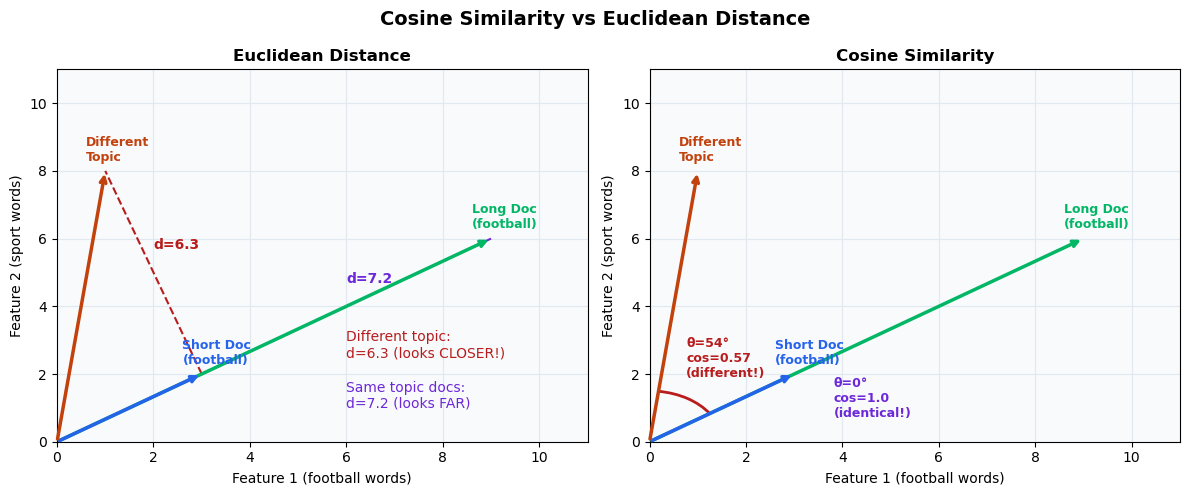

In [213]:
#| code-fold: true
import matplotlib.pyplot as plt
import numpy as np

# Two football documents - same topic, different lengths
short = np.array([3, 2])   # short document
long  = np.array([9, 6])   # long document, same direction
diff  = np.array([1, 8])   # different topic

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Cosine Similarity vs Euclidean Distance', fontsize=14, fontweight='bold')

vectors = {'Long Doc\n(football)': long, 'Short Doc\n(football)': short, 'Different\nTopic': diff}
colors  = ['#01b665', '#2563EB', '#C2410C']

for ax, (title, metric) in zip(axes, [('Euclidean Distance', 'euclidean'), ('Cosine Similarity', 'cosine')]):
    ax.set_xlim(0, 11)
    ax.set_ylim(0, 11)
    ax.set_facecolor('#F8FAFC')
    ax.grid(True, color='#E2E8F0')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1 (football words)')
    ax.set_ylabel('Feature 2 (sport words)')

    # Draw vectors
    for (label, vec), color in zip(vectors.items(), colors):
        ax.annotate('', xy=vec, xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
        ax.text(vec[0]-0.4, vec[1]+0.3, label, color=color, fontweight='bold', fontsize=9)

    if metric == 'euclidean':
        # Draw euclidean distances as dashed lines
        for (l1, v1), (l2, v2), color in [
            (list(vectors.items())[0], list(vectors.items())[1], '#6D28D9'),
            (list(vectors.items())[1], list(vectors.items())[2], '#B91C1C'),
        ]:
            ax.plot([v1[0], v2[0]], [v1[1], v2[1]], '--', color=color, lw=1.5)
            mid = (v1 + v2) / 2
            dist = np.linalg.norm(v1 - v2)
            ax.text(mid[0], mid[1]+0.7, f'd={dist:.1f}', fontsize=10, color=color, fontweight='bold')

        ax.text(6, 1, 'Same topic docs:\nd=7.2 (looks FAR)', color='#6D28D9', fontsize=10)
        ax.text(6, 2.5, 'Different topic:\nd=6.3 (looks CLOSER!)', color='#B91C1C', fontsize=10)

    else:
        # Draw angle arcs for cosine
        for (l1, v1), (l2, v2), color, label in [
            (list(vectors.items())[0], list(vectors.items())[1], '#6D28D9', 'θ=0°\ncos=1.0\n(identical!)'),
            (list(vectors.items())[0], list(vectors.items())[2], '#B91C1C', 'θ=54°\ncos=0.57\n(different!)'),
        ]:
            angle1 = np.degrees(np.arctan2(v1[1], v1[0]))
            angle2 = np.degrees(np.arctan2(v2[1], v2[0]))
            arc = plt.matplotlib.patches.Arc((0,0), 3, 3,
                  angle=0, theta1=min(angle1,angle2), theta2=max(angle1,angle2),
                  color=color, lw=2)
            ax.add_patch(arc)
            mid_angle = np.radians((angle1 + angle2) / 2)
            ax.text(10*np.cos(mid_angle)-4.5, 4*np.sin(mid_angle)-1.5, label,
                    color=color, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [217]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

corpus = [
    'I enjoy playing football and watching football matches',    # D0
    'Football is a team sport played on a grass field',          # D1
    'Python programming is used for data science',               # D2
    'Data science uses statistics and programming',              # D3
    'The president signed a new climate policy today',           # D4
]
display(corpus)
vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(corpus)
sim = cosine_similarity(tfidf).round(3)

print('       D0     D1     D2     D3     D4')
for i, row in enumerate(sim):
    print(f'  D{i}  {row}')

# Most similar to D0
scores = sim[0].copy()
scores[0] = -1   # exclude self

print(f'\nMost similar to D0: D{np.argmax(scores)}')

['I enjoy playing football and watching football matches',
 'Football is a team sport played on a grass field',
 'Python programming is used for data science',
 'Data science uses statistics and programming',
 'The president signed a new climate policy today']

       D0     D1     D2     D3     D4
  D0  [1.    0.179 0.    0.113 0.   ]
  D1  [0.179 1.    0.102 0.    0.   ]
  D2  [0.    0.102 1.    0.384 0.   ]
  D3  [0.113 0.    0.384 1.    0.   ]
  D4  [0. 0. 0. 0. 1.]

Most similar to D0: D1


### 7.2 Real-World Application: Duplicate Article Detection

In [225]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

articles = [
    'Apple releases new iPhone with improved camera system',
    'Apple launches latest iPhone featuring enhanced camera',
    'Google announces new Android update with security fixes',
    'Microsoft reports strong quarterly earnings results',
    'New iPhone from Apple includes better camera features',
]

tfidf = TfidfVectorizer().fit_transform(articles)
sim = cosine_similarity(tfidf)

THRESHOLD = 0.1
for i in range(len(articles)):
    for j in range(i+1, len(articles)):
        if sim[i][j] > THRESHOLD:
            print(f'Duplicate pair (similarity={sim[i][j]:.3f}):')
            print(f'  "{articles[i]}"')
            print(f'  "{articles[j]}"')

Duplicate pair (similarity=0.249):
  "Apple releases new iPhone with improved camera system"
  "Apple launches latest iPhone featuring enhanced camera"
Duplicate pair (similarity=0.177):
  "Apple releases new iPhone with improved camera system"
  "Google announces new Android update with security fixes"
Duplicate pair (similarity=0.319):
  "Apple releases new iPhone with improved camera system"
  "New iPhone from Apple includes better camera features"
Duplicate pair (similarity=0.242):
  "Apple launches latest iPhone featuring enhanced camera"
  "New iPhone from Apple includes better camera features"


### 7.3 Where Cosine Similarity Fails

In [227]:
# The vocabulary mismatch problem
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pairs = [
    ('car insurance coverage',      'automobile protection policy'),
    ('happy joyful cheerful mood',  'sad unhappy gloomy feeling'),
    ('the cat sat on the mat',      'the cat sat on the mat'),   # identical
]

for d1, d2 in pairs:
    vec = TfidfVectorizer()
    X = vec.fit_transform([d1, d2])
    sim = cosine_similarity(X[0], X[1])[0][0]
    print(f'Similarity={sim:.3f}  "{d1[:30]}" vs "{d2[:30]}"')

Similarity=0.000  "car insurance coverage" vs "automobile protection policy"
Similarity=0.000  "happy joyful cheerful mood" vs "sad unhappy gloomy feeling"
Similarity=1.000  "the cat sat on the mat" vs "the cat sat on the mat"


Synonyms score $0$. Antonyms also score $0$. Only exact vocabulary overlap matters.



## 8. Naive Bayes for Text Classification

Imagine we are building a **Spam Filter** for emails.

We want to classify an email as either **Spam** or **Not Spam**.

We notice that spam emails often contain words like "free," "winner," and "click." But legitimate emails also sometimes contain these words. For example:
- *"You are free to download the report."* (Not Spam)
- *"You are our winner! Click here for free prize."* (Spam)

If we write a simple rule like `IF contains "free" THEN Spam`, we will make mistakes.

**The problem:** we need a way to handle **uncertainty**. we want to know: *Given that an email contains the word "free," what is the probability it is spam?*

This is where **Bayes' Theorem** comes in. It helps us in asking:
- "If email contains 'free', how likely is it to be spam?"

**Why is this powerful?**
1.  It handles uncertainty with probabilities.
2.  It can combine evidence from multiple features (multiple words).
3.  It's fast and works surprisingly well for text classification.

<div class="alert alert-primary"> 

**Naive Bayes is the first full text classifier.** It takes a BoW representation and outputs a class label, using probability theory.

 </div>

### 8.1 Bayes' Theorem (The Foundation)

Here is the formula:

$$P(A\mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$

Let's translate this into plain English:

| Symbol | Name | Plain English |
|--------|------|----------------|
| $P(A \mid B)$ | **Posterior** | Probability of A **given** that B happened. (What we want) |
| $P(B \mid A)$ | **Likelihood** | Probability of B **given** that A is true. (What we know from data) |
| $P(A)$ | **Prior** | Initial belief about A before seeing any evidence. |
| $P(B)$ | **Evidence** | Overall probability of B occurring. (Normalizing constant) |

**Example:**

- $A$ = Email is Spam
- $B$ = Email contains the word "free"

Then:
$P(\text{Spam}|\text{free}) = {\large\frac{P(\text{free}|\text{Spam}) \cdot P(\text{Spam})}{P(\text{free})}}$

- $P(\text{Spam}|\text{free})$: Probability it's spam given it says "free" — **this is what we want to predict.**
- $P(\text{free}|\text{Spam})$: Of all spam emails, what fraction contain "free"? (We can calculate this from historical data)
- $P(\text{Spam})$: What fraction of all emails are spam? (Prior belief)
- $P(\text{free})$: What fraction of all emails contain "free"? (Rarely calculated directly; it's often treated as a normalizer)
<p>

**In classification, with multiple features:**

- $C$ = class (e.g., spam, not spam)
- $F_1, F_2, \dots, F_n$ = features (e.g., words)

We want:  
$$
P(C \mid F_1, F_2, \dots, F_n) = \frac{P(C) \cdot P(F_1, F_2, \dots, F_n \mid C) }{P(F_1, F_2, \dots, F_n)}
$$

Because the evidence is constant across classes, we can compare unnormalized scores:

$$
{P(C \mid F_1, F_2, \dots, F_n) \propto P(C) \cdot P(F_1, F_2, \dots, F_n \mid C)}
$$


### 8.2 The 'Naive' Independence Assumption

In real classification, we have **multiple features**. For an email:

- Feature 1: contains "free"?
- Feature 2: contains "winner"?
- Feature 3: contains "click"?

Bayes' Theorem with multiple features becomes:

$P(\text{Spam} | w_1, w_2, w_3) = \frac{P(w_1, w_2, w_3 | \text{Spam}) \cdot P(\text{Spam})}{P(w_1, w_2, w_3)}$

The challenge is calculating $P(w_1, w_2, w_3 | Spam)$ — the probability of seeing **all three words together** in a spam email. If we try to compute this directly, we need an enormous amount of data to cover all possible combinations.

**The Naive Assumption:** We assume that **all features are independent given the class**.

That means:

$P(w_1, w_2, w_3 | \text{Spam}) = P(w_1 | \text{Spam}) \cdot P(w_2 | \text{Spam}) \cdot P(w_3 | \text{Spam})$

This assumption is almost always **false** in reality (words in an email are not independent). But it simplifies the calculation dramatically and often yields excellent results in practice.

**With this assumption:**

With this assumption:

<div class="alert alert-secondary"> 

$$
P(C \mid \text{features}) \propto P(C) \cdot \prod_{i=1}^{n} P(F_i \mid C)
$$

</div>

### 8.3 Full Classification Rule

For a classification problem, we compute the posterior for **each class** and pick the class with the highest probability.

For Spam vs Not Spam:

$P(\text{Spam} | \text{features}) \propto P(\text{Spam}) \cdot \prod_{i} P(\text{feature}_i | \text{Spam})$

$P(\text{Not Spam} | \text{features}) \propto P(\text{Not Spam}) \cdot \prod_{i} P(\text{feature}_i | \text{Not Spam})$

We compare these two values and choose the larger one.
<div class="alert alert-secondary"> 

$$
\hat{C} = \arg\max_{C} \left[ P(C) \prod_{i=1}^{n} P(F_i \mid C) \right]
$$

</div>

To avoid numerical underflow (multiplying many small numbers), we often work with **logarithms**:

$$
\log P(C \mid \text{features}) \propto \log P(C) + \sum_{i=1}^{n} \log P(F_i \mid C)
$$

The class with the largest log‑score is chosen.

### 8.4 Numerical Example with Bayes Theorem on a Tiny Dataset

We’ll use a small email dataset with two binary features: whether the email contains the words **free** and **winner**.

| Email ID | Contains "free" | Contains "winner" | Class |
|----------|----------------|------------------|-------|
| 1 | Yes | Yes | Spam |
| 2 | Yes | No | Spam |
| 3 | No | Yes | Spam |
| 4 | No | No | Not Spam |
| 5 | Yes | No | Not Spam |
| 6 | No | No | Not Spam |

**Step 1: Calculate Priors $P(\text{Class})$**

- Total emails: $6$
- Spam emails: $3$
- Not Spam emails: $3$

$P(\text{Spam}) = \frac{3}{6} = 0.5$, 

$P(\text{Not Spam}) = \frac{3}{6} = 0.5$



**Step 2: Calculate Likelihoods $P(\text{feature}|\text{class})$**

We need:

- $P(\text{free}|\text{Spam})$
- $P(\text{Not free}|\text{Spam})$
- $P(\text{free}|\text{Not Spam})$
- $P(\text{Not free}|\text{Not Spam})$
- $P(\text{winner}|\text{Spam})$
- $P(\text{Not winner}|\text{Spam})$
- $P(\text{winner}|\text{Not Spam})$
- $P(\text{Not winner}|\text{Not Spam})$

<p>

| Feature | Value | Spam (N=3) | Not Spam (N=3) |
|---------|-------|------------|----------------|
| **free** | yes | $P(\text{free}\|\text{Spam}) = 2/3$ | $P(\text{free}\|\text{Not Spam}) = 1/3$ |
| **free** | no  | $P(\text{not free}\|\text{Spam}) = 1/3$ | $P(\text{not free}\|\text{Not Spam}) = 2/3$ |
| **winner** | yes | $P(\text{winner}\|\text{Spam}) = 2/3$ | $P(\text{winner}\|\text{Not Spam}) = 0/3 = 0$ |
| **winner** | no  | $P(\text{not winner}\|\text{Spam}) = 1/3$ | $P(\text{not winner}\|\text{Not Spam}) = 3/3 = 1$ |



**Step 3: Make a Prediction**

Let's predict a **new email**:

- Contains "free"? Yes
- Contains "winner"? No

**Calculate Spam Score:**

$P(\text{Spam}) \times P(\text{free}|\text{Spam}) \times P(\text{not winner}|\text{Spam})$
$= 0.5 \times 2/3 \times 1/3$
$= 0.5 \times 0.222$
$= 0.111$

**Calculate Not Spam Score:**

$P(\text{Not Spam}) \times P(\text{free}|\text{Not Spam}) \times P(\text{not winner}|\text{Not Spam})$
$= 0.5 \times 1/3 \times 1$
$= 0.5 \times 0.333$
$= 0.1665$

**Decision:** Not Spam ($0.1665 > 0.111$)

### 8.5 Issue of Zero Probability 

**Predict a new email** 

- free=yes, 
- winner=yes

$$
\begin{aligned}
P(\text{spam} \mid \text{features}) &\propto P(\text{Spam}) \times P(\text{free}|\text{Spam}) \times P(\text{winner}|\text{Spam}) \\ &=0.5 \times 2/3 \times 2/3 = 0.222 \\
P(\text{not spam} \mid \text{features}) &\propto P(\text{not spam}) \times P(\text{free}|\text{not spam}) \times P(\text{winner}|\text{not spam}) \\&=0.5 \times 1/3 \times 0 = 0
\end{aligned}
$$

- When a particular feature value never appears in a class during training, the maximum likelihood estimate gives a probability of zero.
- This causes the entire posterior probability for that class to become zero, regardless of other evidence. 
- To avoid this, we add a small pseudo‑count $\alpha$ (usually $\alpha = 1$) to all counts. However, the way we apply smoothing depends on **how we interpret the features**.

There are two common variants used in text classification:  

- **Bernoulli Naive Bayes** – treats each feature as binary (present/absent).  
- **Multinomial Naive Bayes** – treats each feature as a count (e.g., word frequency).  

The smoothing formulas differ because the denominator represents different things.

$$
\hat{P}(\text{value} \mid \text{class}) = \frac{\text{count}(\text{value}, \text{class}) + \alpha}{N_y + \alpha \cdot n}
$$

Where:

- $N_y$ = number of samples of class $y$
- $n$ = number of distinct values the feature can take

**Applying Laplace smoothing ($\alpha=1$) to our example** (binary features, $n=2$):

#### 8.5.1 Bernoulli Naive Bayes (Binary Features)

In Bernoulli NB, each feature $i$ can take only two values (e.g., $0$ or $1$). For a given class $y$, we estimate:

$$
P(\text{feature}_i = 1 \mid y) = \frac{N_{yi} + \alpha}{N_y + \alpha \cdot n_i}
$$

where:

- $N_{yi}$ = number of samples in class $y$ where feature $i = 1$  
- $N_y$ = total number of samples in class $y$  
- $n_i$ = number of **possible values** for feature $i$ (for binary, $n_i = 2$)  
- $\alpha$ = smoothing parameter (Laplace smoothing uses $\alpha = 1$)

Because each binary feature has exactly two possible values (0 and 1), the denominator uses $n_i = 2$ for every feature. This ensures that the probabilities for the two outcomes sum to 1.

**Example with our tiny dataset (binary features: free, winner):**

| Email | free | winner | class     |
|-------|------|--------|-----------|
| 1     | 1    | 1      | spam      |
| 2     | 1    | 0      | spam      |
| 3     | 0    | 1      | spam      |
| 4     | 0    | 0      | not spam  |
| 5     | 1    | 0      | not spam  |
| 6     | 0    | 0      | not spam  |
<p>

| Class | $N_y$ | $N_{\text{free}=1}$ | $N_{\text{winner}=1}$ |
|---|---|---|---|
| spam  | 3      | 2            | 2              |
| not spam | 3   | 1            | 0              |

**Step 1 – Compute Priors**  
$P(\text{spam}) = {\large\frac{3}{6}} = 0.5, \quad P(\text{not spam}) = {\large\frac{3}{6}} = 0.5$

**Step 2 – Compute Likelihoods (with Laplace smoothing, $\alpha=1$)**  

For each class, $N_y = 3$. Each binary feature has $n_i = 2$.

- **Spam class:**  
  $N_{\text{free}=1} = 2, \quad N_{\text{winner}=1} = 2$  

  $\Rightarrow P(\text{free}=1 \mid \text{spam}) = {\large\frac{2 + 1}{3 + 2}} = {\large\frac{3}{5}} = 0.6$

  $\Rightarrow P(\text{winner}=1 \mid \text{spam}) = {\large\frac{2 + 1}{3 + 2}} = 0.6$

- **Not spam class:**  
  $N_{\text{free}=1} = 1,\quad N_{\text{winner}=1} = 0$  

  $\Rightarrow P(\text{free}=1 \mid \text{not spam}) = {\large\frac{1 + 1}{3 + 2}} = {\large\frac{2}{5}} = 0.4$

  $\Rightarrow P(\text{winner}=1 \mid \text{not spam}) = {\large\frac{0 + 1}{3 + 2}} = {\large\frac{1}{5}} = 0.2$

**Step 3 – Predict a new email with free=1, winner=1**  

Compute unnormalized posterior (proportional) scores:

$$
\begin{aligned}
\text{Score(spam)} &= P(\text{spam}) \times P(\text{free}=1 \mid \text{spam}) \times P(\text{winner}=1 \mid \text{spam})\\ 
&= 0.5 \times 0.6 \times 0.6 = 0.18
\\\text{Score(not spam)} &= P(\text{not spam}) \times P(\text{free}=1\mid\text{not spam}) \times P(\text{winner}=1\mid\text{not spam})
\\ 
&= 0.5 \times 0.4 \times 0.2 = 0.04
\end{aligned}
$$

**Step 4 – Normalize to obtain probabilities**

$$
\begin{aligned}
\text{Total} &= 0.18 + 0.04 = 0.22
\\ P(\text{spam} \mid \text{data}) &= \frac{0.18}{0.22} \approx 0.818
\\ P(\text{not spam} \mid \text{data}) &= \frac{0.04}{0.22} \approx 0.182
\end{aligned}
$$

The email is classified as **spam** with $≈81.8%$ probability.

**Sklearn implementation:**

In [260]:
import numpy as np
from sklearn.naive_bayes import BernoulliNB

# Dataset: features [free, winner] with 1=yes, 0=no
X = np.array([[1,1], [1,0], [0,1], [0,0], [1,0], [0,0]])
y = np.array(['spam', 'spam', 'spam', 'not_spam', 'not_spam', 'not_spam'])

# Bernoulli Naive Bayes
bnb = BernoulliNB(alpha=1.0)
bnb.fit(X, y)

# Predict for new email: free=1, winner=1
probs_bnb = bnb.predict_proba([[1,1]])[0]
print("BernoulliNB probabilities:")
print(f"  not_spam: {probs_bnb[0].round(3)}")
print(f"  spam:     {probs_bnb[1].round(3)}")
print(f"  Prediction: {bnb.predict([[1,1]])[0]}")

BernoulliNB probabilities:
  not_spam: 0.182
  spam:     0.818
  Prediction: spam


#### 8.5.2 Multinomial Naive Bayes (Count Features)

In Multinomial NB, each feature $i$ represents a count (e.g., how many times a word appears). The parameters for a given class $y$, $P(\text{feature}_i \mid y)$ are estimated as:

$$
P(\text{feature}_i \mid y) = \frac{T_{yi} + \alpha}{T_y + \alpha \cdot n}
$$

where:

- $T_{yi}$ = **total sum** of feature $i$ across all samples in class $y$ (i.e., sum of counts)  
- $T_y = \sum_{i=1}^{n} T_{yi}$ = total sum of **all features** in class $y$  
- $n$ = number of **features** (vocabulary size)  
- $\alpha$ = smoothing parameter

When our data are binary ($0$ or $1$) as in the tiny dataset, each $T_{yi}$ is simply the number of times feature $i$ equals $1$ in class $y$, and $T_y$ is the total number of 1’s across all features in that class.

**Using the same dataset:**

| Email | free | winner | class     |
|-------|------|--------|-----------|
| 1     | 1    | 1      | spam      |
| 2     | 1    | 0      | spam      |
| 3     | 0    | 1      | spam      |
| 4     | 0    | 0      | not spam  |
| 5     | 1    | 0      | not spam  |
| 6     | 0    | 0      | not spam  |
<p>

| Class | $T_y$ | $T_{\text{free}}$ | $T_{\text{winner}}$ |
|---|---|---|---|
| spam  | 4      | 2            | 2              |
| not spam | 1   | 1            | 0              |


**Step 1 – Priors** (same as before)  
$P(\text{spam}) = 0.5,\quad P(\text{not spam}) = 0.5$

**Step 2 – Compute Likelihoods (with Laplace smoothing, $\alpha=1$)**  

Number of features $n = 2$.

- **Spam class:**  
  $T_{\text{free}} = 2$ (sum of free column for spam emails: 1+1+0)  
  $T_{\text{winner}} = 2$ (1+0+1)  
  $T_y = 2 + 2 = 4$  

  $\Rightarrow P(\text{free} \mid \text{spam}) = {\large\frac{2 + 1}{4 + 1 \cdot 2}} = {\large\frac{3}{6}} = 0.5$

  $\Rightarrow P(\text{winner} \mid \text{spam}) = {\large\frac{2 + 1}{4 + 2}} = 0.5$

- **Not spam class:**  
  $T_{\text{free}} = 1$ (from email 5)  
  $T_{\text{winner}} = 0$  
  $T_y = 1 + 0 = 1$  

  $\Rightarrow P(\text{free} \mid \text{not spam}) = {\large\frac{1 + 1}{1 + 2} = \frac{2}{3}} \approx 0.667$
  
  $\Rightarrow P(\text{winner}=1 \mid \text{not spam}) = {\large\frac{0 + 1}{1 + 2}} = {\large\frac{1}{3}} \approx 0.333$

**Step 3 – Predict a new email with free=1, winner=1**  

$$\begin{aligned}
\text{Score(spam)} &= P(\text{spam}) \times P(\text{free} \mid \text{spam}) \times P(\text{winner} \mid \text{spam})
\\
&= 0.5 \times 0.5 \times 0.5 = 0.125
\\
\text{Score(not spam)} &= P(\text{not spam}) \times P(\text{free} \mid \text{not spam}) \times P(\text{winner} \mid \text{not spam})
\\
&= 0.5 \times 2/3 \times 1/3 = 0.111
\end{aligned}$$

**Step 4 – Normalize**

$$\begin{aligned}
\text{Total} &= 0.125 + 0.111 = 0.236
\\
P(\text{spam} \mid \text{data}) &= \frac{0.125}{0.236} \approx 0.529
\\
P(\text{not spam} \mid \text{data}) &= \frac{0.111}{0.236} \approx 0.471
\end{aligned}$$

**Sklearn implementation:**

In [259]:
import numpy as np
from sklearn.naive_bayes import MultinomialNB

# Dataset: features [free, winner] with 1=yes, 0=no
X = np.array([[1,1], [1,0], [0,1], [0,0], [1,0], [0,0]])
y = np.array(['spam', 'spam', 'spam', 'not_spam', 'not_spam', 'not_spam'])

# Multinomial Naive Bayes
mnb = MultinomialNB(alpha=1.0)
mnb.fit(X, y)

probs_mnb = mnb.predict_proba([[1,1]])[0]
print("MultinomialNB probabilities:")
print(f"  not_spam: {probs_mnb[0].round(3)}")
print(f"  spam:     {probs_mnb[1].round(3)}")
print(f"  Prediction: {mnb.predict([[1,1]])[0]}")

MultinomialNB probabilities:
  not_spam: 0.471
  spam:     0.529
  Prediction: spam


The email is again classified as **spam**, but with a lower confidence (~52.9%) compared to Bernoulli NB (~81.8%). This illustrates how the choice of model can affect the output probabilities.

Scikit‑learn returns probabilities in the order of `classes_` (alphabetical by default). In our case, `classes_ = ['not_spam', 'spam']`. So:

- The first probability is for `not_spam`
- The second is for `spam`

This ordering is consistent across both `BernoulliNB` and `MultinomialNB`.

#### 8.5.3 Comparison of Smoothing for the Two Variants

| Variant            | Formula | Denominator Meaning | When to Use |
|--------------------|---------|---------------------|-------------|
| **BernoulliNB**    | $\large\frac{N_{yi} + \alpha}{N_y + \alpha \cdot 2}$ | Number of samples | Binary features (presence/absence) |
| **MultinomialNB**  | $\large\frac{T_{yi} + \alpha}{T_y + \alpha \cdot n}$ | Total sum of all feature counts | Count features (e.g., word frequencies) |

#### 8.5.4 Why the Two Variants Give Different Probabilities

- **BernoulliNB** models each feature as a separate Bernoulli trial. The denominator in smoothing uses the number of samples + 2, so the smoothing effect is stronger when the number of samples is small.  
- **MultinomialNB** models the feature vector as a single multinomial draw. The denominator uses the total feature sum + number of features. Because the total feature sum can be much larger than the number of samples, the smoothing effect can be weaker or stronger depending on the data.

Both models are correct under their respective assumptions. The choice depends on the nature of the features and the problem. In text classification:

- Use **BernoulliNB** when features are binary (e.g., word presence/absence) and document lengths vary widely.  
- Use **MultinomialNB** when features are counts (e.g., word frequencies) and you want to account for how many times a word appears.

#### 8.5.5 When to Use BernoulliNB vs. MultinomialNB

| **BernoulliNB** | **MultinomialNB** |
|-----------------|-------------------|
| **Features are binary** (0 or 1). Examples: word presence (does the word appear?), boolean flags, or binarized counts (e.g., “contains at least one keyword”). | **Features are counts** (non‑negative integers). Examples: word frequencies, term counts, TF‑IDF values. |
| **Suitable for:** short texts (tweets, short messages) where multiple occurrences of a word don’t add much information; any situation where you care only whether a feature is present or absent. | **Suitable for:** longer documents where word frequency matters; standard bag‑of‑words or TF‑IDF representations. |
| **When to avoid:** When the magnitude of counts is important (e.g., “movie” appears 5 times vs 1 time). | **When to avoid:** When features are truly binary and you want to penalize absence (Bernoulli does that naturally). |

**Quick Decision Guide**

- If the feature matrix contains **only 0s and 1s** → try **BernoulliNB**.
- If the feature matrix contains **counts (0,1,2,…)** → use **MultinomialNB** (or binarize them if you prefer Bernoulli).
- If the features are **continuous** → use **GaussianNB** (or discretize).
- If the data is **imbalanced** and you are using MultinomialNB → consider **ComplementNB** (a variant that often works better for imbalanced text data).

> Both are fast, easy to interpret, and serve as excellent baselines for text classification. When in doubt, evaluate both on your validation set and choose the one with higher accuracy.

### 8.6 Real‑World Example – Sentiment Analysis

In [258]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Sample dataset
reviews = [
    "I loved this movie, it was fantastic!",
    "Worst film ever, terrible acting.",
    "Great story and amazing performances.",
    "Boring, slow, and predictable.",
    "Excellent cinematography, highly recommend.",
    "Not worth the time, very disappointing."
]
sentiments = ["positive", "negative", "positive", "negative", "positive", "negative"]

# Convert text to bag-of-words
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(reviews)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, sentiments, test_size=0.3, random_state=42
)

# Train Complement Naive Bayes
model = MultinomialNB(alpha=1.0)
model.partial_fit(X_train, y_train, classes=np.unique(sentiments))

# Predict on test set
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# Predict a new review
new_review = ["This movie is fantastic"]
new_vec = vectorizer.transform(new_review)
print("\nNew review prediction:", model.predict(new_vec)[0])
print("Prediction probabilities:", model.predict_proba(new_vec).round(3)[0])

Accuracy: 0.5

Classification Report:
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00         1
    positive       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2


New review prediction: positive
Prediction probabilities: [0.481 0.519]


### 8.7 Importance of Naive Bayes in NLP

Naive Bayes holds a special place in Natural Language Processing (NLP) for several reasons:

1. **Perfect Match with Bag‑of‑Words** – The assumption of feature independence aligns with the bag‑of‑words representation, where word order is ignored.
2. **Handles High‑Dimensional Sparse Data** – Text data has thousands of features; Naive Bayes scales linearly with the number of features and documents.
3. **Efficient and Fast** – Training and prediction are extremely fast, suitable for real‑time applications like spam filters.
4. **Works Well with Small Datasets** – Requires relatively little training data compared to deep learning models.
5. **Interpretable** – Probabilities can be inspected to understand which words drive classification.
6. **Incremental Learning** – Supports partial fit, allowing models to be updated with new data without retraining from scratch.
7. **Baseline Model** – Often used as a strong baseline in text classification benchmarks.

### 8.8 When NOT to Use Naive Bayes

Despite its strengths, Naive Bayes has limitations:

- **Strong Feature Dependence** – When features are highly correlated (e.g., “good” and “great” in reviews), the independence assumption may hurt performance. More complex models like Logistic Regression or SVM may be better.
- **Word Order Matters** – For tasks where phrase structure or negation is critical (e.g., “not good”), Naive Bayes may fail because it treats each word independently.
- **Continuous Features with Complex Distributions** – Gaussian Naive Bayes assumes normality; if features have different distributions, other classifiers may be more appropriate.
- **Imbalanced Data** – Although priors help, extreme imbalance can still bias predictions. Techniques like oversampling may be needed.
- **State‑of‑the‑Art Performance** – For complex tasks like question answering or machine translation, deep learning models (e.g., BERT) far outperform Naive Bayes.

## 9. Two Approaches to NLP

| Dimension | Rule-Based (Regex) | Statistical / ML |
|---|---|---|
| Core idea | Hand-craft explicit rules | Learn patterns from labeled data |
| Strengths | Precise, interpretable, no data needed | Scalable, handles ambiguity, generalizes |
| Weaknesses | Brittle, labor-intensive | Needs labeled data, less interpretable |
| Best for | Narrow structured patterns | Broad tasks with sufficient training data |
| Still used today? | Yes — dates, codes, IDs, emails | Yes — almost everything else |
<p>

> **Real-world pattern:** Rule-based handles structured extraction (always-on precision). ML handles ambiguous classification (coverage and generalization). Combine both for best results.

## 10. Why Classical NLP Hit a Wall

### 10.1 Vocabulary Explosion

Classical NLP approaches often rely on **bag‑of‑words** or **n‑gram** representations. While this is simple, it faces a fundamental scalability problem: the number of possible features grows combinatorially with the size of the n‑gram.

- For a vocabulary of size $V$, there are up to $V^n$ possible n‑grams (in reality, many are unobserved). 
- As $n$ increases, the feature space explodes, leading to extremely sparse vectors.  
- Sparse high‑dimensional data introduces:
  - **Computational inefficiency**: memory and time costs increase.  
  - **Data sparsity**: most features are zero for any given document, making probability estimates unreliable.  
  - **Curse of dimensionality**: models require exponentially more data to generalise well.

This forces practitioners to either:

- Restrict to unigrams or bigrams only, losing longer‑range patterns.
- Apply feature selection or dimensionality reduction (e.g., PCA, SVD) – but those are also limited by scale.
- Move to distributed representations (embeddings) that encode semantics in lower‑dimensional dense vectors.

In [275]:
from sklearn.feature_extraction.text import CountVectorizer

sample_texts = [
    'machine learning is powerful',
    'deep learning uses neural networks',
    'NLP processes natural language text',
    'transformers changed the NLP landscape',
]
for ngram in [(1,1), (1,2), (1,3)]:
    vec = CountVectorizer(ngram_range=ngram)
    X = vec.fit_transform(sample_texts)
    density = X.nnz / (X.shape[0] * X.shape[1])
    print(f'{ngram[1]}-gram: vocab={X.shape[1]}, density={density*100:.1f}% non-zero entries')

1-gram: vocab=17, density=27.9% non-zero entries
2-gram: vocab=32, density=26.6% non-zero entries
3-gram: vocab=43, density=26.2% non-zero entries


As N increases, density drops and zero becomes more. Scale to real corpora and the vectors become computationally impractical.

### 10.2 No semantic meaning

Classical NLP treats words as separate symbols—like "car" and "automobile" are just different labels.
So even if two sentences mean the same thing, if they use different words, the model sees them as completely different.

In [280]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pairs = [
    ('The car needs repair',    'This automobile require fixing'),   # synonyms
    ('I am happy today',        'I want a car today'),           # synonyms
    ('The cat sat down',        'The dog sat down'),              # diff topic, shared words
]

for d1, d2 in pairs:
    vec = TfidfVectorizer()
    X = vec.fit_transform([d1, d2])
    sim = cosine_similarity(X[0], X[1])[0][0]
    print(f'Sim={sim:.3f}  |  "{d1}" vs "{d2}"')

Sim=0.000  |  "The car needs repair" vs "This automobile require fixing"
Sim=0.202  |  "I am happy today" vs "I want a car today"
Sim=0.603  |  "The cat sat down" vs "The dog sat down"


The code shows that sentences with synonyms get a similarity score of $0$, while sentences that share words (even on different topics) get a positive score.

In short: Word‑based models measure exact word overlap, not meaning. That’s a major limitation.



### 10.3 Word Order Is Lost

Classical bag‑of‑words models treat a sentence as a set of words. Order doesn’t matter.

In [281]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

sentences = [
    'The cat ate the fish', # cat is the actor
    'The fish ate the cat', # fish is the actor — very different meaning
    'ate cat fish the the', # random word order, same words
]

vec = CountVectorizer()
X = vec.fit_transform(sentences).toarray()
print('All three vectors identical?', np.all(X == X[0]))

All three vectors identical? True


 The model cannot tell who did what to whom. Word order carries essential meaning, but classical NLP discards it.

### 10.4 Context-Free Word Meaning (Polysemy)

In classical NLP, each word is treated as a discrete atomic unit. A word like "bank" has a single, fixed representation regardless of its surrounding context. This means:

The model cannot distinguish between polysemous words (words with multiple meanings) based on usage.

In [289]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

sentences = [
    'I deposited money at the bank',        # financial bank
    'I sat by the river bank',     # river bank
]

vec = TfidfVectorizer()
X = vec.fit_transform(sentences).toarray()
features = vec.get_feature_names_out()
bank_idx = list(features).index('bank')

for i, s in enumerate(sentences):
    print(f'S{i+1}: TF-IDF("bank") = {X[i, bank_idx]:.4f}  -- "{s}"')

print()
print('"bank" has the SAME vector in both contexts even when context is different')

S1: TF-IDF("bank") = 0.3552  -- "I deposited money at the bank"
S2: TF-IDF("bank") = 0.3552  -- "I sat by the river bank"

"bank" has the SAME vector in both contexts even when context is different


Classical models cannot handle polysemy; each word has one meaning, ignoring the rich contextual nuance that gives words their precise sense.

### 10.5 Long range dependencies
Classical models like n‑gram language models or bag‑of‑words have a fixed context window. They cannot capture dependencies that span many words—for example, subject‑verb agreement in a long sentence, or coreference (e.g., “The man who … … … he …”).

### 10.6 Lack of Compositionality

Words combine to form meaning in ways that are not simply additive. Bag‑of‑words models treat each word independently, so they cannot model negation, intensifiers, or phrase‑level semantics. For example, “not good” and “good” are represented similarly, despite opposite meanings.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

phrases = [
    "This product is good",
    "This product is not good",
    "This product is bad"
]

vec = TfidfVectorizer()
X = vec.fit_transform(phrases)

sim_good_not = cosine_similarity(X[0], X[1])[0][0]
sim_good_bad = cosine_similarity(X[0], X[2])[0][0]

print(f"Similarity('good', 'not good') = {sim_good_not:.3f}")
print(f"Similarity('good', 'bad')      = {sim_good_bad:.3f}")

Similarity('good', 'not good') = 0.787
Similarity('good', 'bad')      = 0.574


### 10.7 Domain Adaptation / Transfer Learning
A model trained on one corpus (e.g., news articles) uses vocabulary and co‑occurrence statistics that do not generalise to a different domain (e.g., medical texts). Classical models have no built‑in mechanism to transfer knowledge across domains; retraining from scratch is required.

### 10.8 Handling of Unstructured / Multimodal Input

Classical models are limited to a single modality. They cannot leverage the rich context available in images, sound, or structured data without custom feature engineering that often discards important information.

## 11. What each Limitation Motivated

| Classical NLP Limitation | Neural Solution | 
|---|---|
| Sparse, huge vocabulary vectors | Dense word embeddings (Word2Vec) | 
| No semantic meaning between words | Word2Vec, GloVe | 
| Word order ignored | RNNs, LSTMs, Transformers | 
| Context-free word meaning | BERT contextual embeddings | 
| Poor cross-domain generalization | Transfer learning, fine-tuning | 
| Feature engineering bottleneck | End-to-end deep learning |